In [1]:
%pip install torch torchvision matplotlib

Device: cpu
Batch: (64, 1, 28, 28) Pixel range: 0.0 1.0


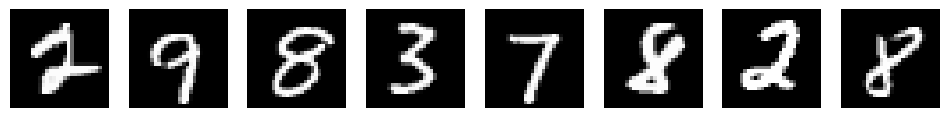

In [23]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 5  # Start with 1 to check your code, then train for 5.
LATENT_CHANNELS = 8
print("Device:", device)

train_data = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
# Fixed random subsets keep the exercise small and comparisons repeatable.
g = torch.Generator().manual_seed(42)
train_data = Subset(train_data, torch.randperm(len(train_data), generator=g)[:5000].tolist())
test_data = Subset(test_data, torch.randperm(len(test_data), generator=g)[:1000].tolist())
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, labels = next(iter(train_loader))
print("Batch:", tuple(images.shape), "Pixel range:", images.min().item(), images.max().item())
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img in zip(axes, images[:8]):
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.show()

Shape Table

Encoder 1: [N, 16, 14, 14]

Encoder 2: [N, 32, 7, 7]

Bottleneck: [N, L, 7, 7]

Decoder 1: [N, 16, 14, 14]

Decoder 2: [N, 1, 28, 28]


Answers

1.
For L = 8

Input values per image = 784

Latent values = 392

Input/latent ratio = 2:1


2.
For L = 32

No. The latent representation contains 1568 values whereas the input contains 784 values, so it is not dimensionally compressed.


3.
The final Sigmoid activation outputs values in the range [0,1], matching the MNIST pixel range produced by ToTensor().


4.
If output_padding = 0

Output height
= (7−1)×2 − 2×1 + 3 + 0
= 13

In [24]:
class Encoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=latent_channels,
                kernel_size=1
            )

        )

    def forward(self, x):
        return self.network(x)

In [25]:
class Decoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()

        self.network = nn.Sequential(

            nn.ConvTranspose2d(
                in_channels=latent_channels,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=16,
                out_channels=1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()

        )

    def forward(self, z):
        return self.network(z)

In [26]:
class ImageEncoderDecoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        return reconstruction, z

In [27]:
# Shape and range checks: run these before training.
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
x = torch.rand(4, 1, 28, 28, device=device)
with torch.no_grad():
    reconstruction, z = model(x)
assert z.shape == (4, LATENT_CHANNELS, 7, 7), "Check encoder stride/padding/channels"
assert reconstruction.shape == x.shape, "Check decoder output_padding"
assert torch.isfinite(reconstruction).all(), "Output contains nonfinite values"
assert ((reconstruction >= 0) & (reconstruction <= 1)).all(), "Check output activation"
print("Input:", tuple(x.shape), "Latent:", tuple(z.shape), "Output:", tuple(reconstruction.shape))
print("Shape and range checks passed")

Input: (4, 1, 28, 28) Latent: (4, 8, 7, 7) Output: (4, 1, 28, 28)
Shape and range checks passed


In [28]:
def train_step(model, images, optimizer, criterion):
    optimizer.zero_grad()
    reconstruction, _ = model(images)
    loss = criterion(reconstruction, images)
    loss.backward()
    optimizer.step()
    return loss.item()

Untrained held-out MSE: 0.18629
Epoch 1: train MSE=0.11827, held-out MSE=0.04370
Epoch 2: train MSE=0.03428, held-out MSE=0.02552
Epoch 3: train MSE=0.01680, held-out MSE=0.00982
Epoch 4: train MSE=0.00826, held-out MSE=0.00614
Epoch 5: train MSE=0.00559, held-out MSE=0.00450


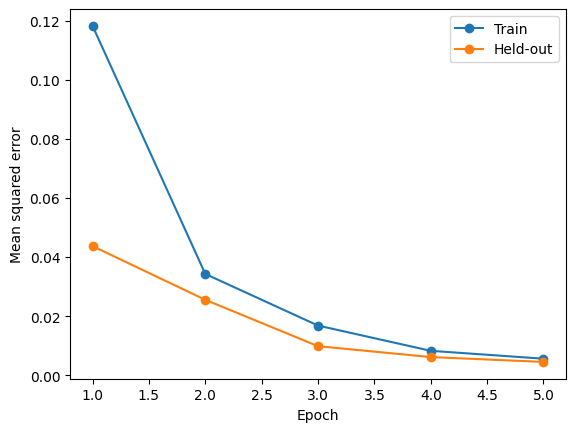

In [29]:
criterion = nn.MSELoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    for images, _ in loader:
        images = images.to(device)
        reconstruction, _ = model(images)
        total_loss += criterion(reconstruction, images).item() * images.size(0)
    return total_loss / len(loader.dataset)

# Re-running this cell starts a fresh model and optimizer.
torch.manual_seed(42)
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
initial_mse = evaluate(model, test_loader)
print(f"Untrained held-out MSE: {initial_mse:.5f}")
history = {"train": [], "test": []}
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        total_loss += train_step(model, images, optimizer, criterion) * images.size(0)
    history["train"].append(total_loss / len(train_loader.dataset))
    history["test"].append(evaluate(model, test_loader))
    print(f"Epoch {epoch + 1}: train MSE={history['train'][-1]:.5f}, "
          f"held-out MSE={history['test'][-1]:.5f}")

plt.plot(range(1, EPOCHS + 1), history["train"], marker="o", label="Train")
plt.plot(range(1, EPOCHS + 1), history["test"], marker="o", label="Held-out")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

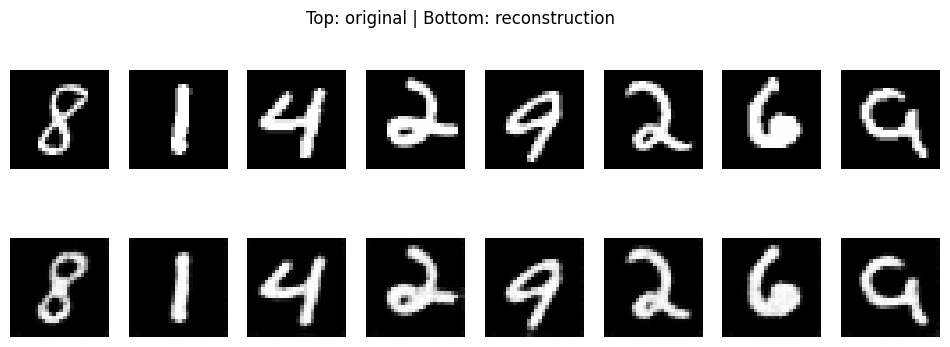

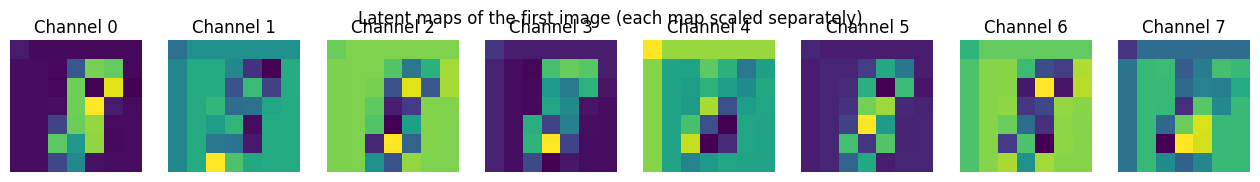

In [30]:
model.eval()
examples, _ = next(iter(test_loader))
with torch.no_grad():
    reconstructed, latents = model(examples[:8].to(device))
reconstructed, latents = reconstructed.cpu(), latents.cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(examples[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
fig.suptitle("Top: original | Bottom: reconstruction")
plt.show()
count = min(LATENT_CHANNELS, 8)
fig, axes = plt.subplots(1, count, figsize=(2 * count, 2), squeeze=False)
for i in range(count):
    axes[0, i].imshow(latents[0, i], cmap="viridis")
    axes[0, i].set_title(f"Channel {i}")
    axes[0, i].axis("off")
fig.suptitle("Latent maps of the first image (each map scaled separately)")
plt.show()

## Bottleneck Experiment Results

| Latent Channels | Values per Image | Input/Latent Ratio | Final Train MSE | Final Held-out MSE | Visible Differences |
|----------------|-----------------|-------------------|----------------|-------------------|--------------------|
| 2 | 98 (2 × 7 × 7) | 8:1 | 0.01210 | 0.01057 | Digits are recognizable but slightly blurry. Some fine details and stroke information are lost due to the small latent space. |
| 8 | 392 (8 × 7 × 7) | 2:1 | 0.00559 | 0.00450 | Good balance between compression and reconstruction quality. Most digits are reconstructed clearly with only minor loss of detail. |
| 32 | 1568 (32 × 7 × 7) | 1:2 | 0.00348 | 0.00313 | Best reconstruction quality. Digits appear sharper and preserve more details because the latent representation can store more information. |

## Discussion

### 1. Did a larger latent improve reconstruction in your runs? Support the answer with images and MSE.

Yes. A larger latent generally improved reconstruction quality. The held-out MSE decreased from 0.01057 (L=2) to 0.00450 (L=8) and further to 0.00313 (L=32). The reconstructed digits also appeared clearer and sharper as the number of latent channels increased.

### 2. Why is spatial downsampling alone insufficient to claim dimensional compression?

Reducing height and width does not always mean compression. The number of channels can increase at the same time. Compression should be measured by the total number of values in the tensor, not only by the image size.

### 3. Why can the decoder restore image size without recovering every original detail?

The decoder can increase the image size back to 28 × 28, but information lost in the bottleneck cannot be perfectly recovered. Therefore, the reconstructed image may look similar to the original but may miss some details.

### 4. How would a [N, 128] vector differ from this spatial latent?

A [N, 128] vector stores information as a single flat feature vector. The spatial latent used in this lab keeps the 7 × 7 spatial structure, which helps preserve location information in the image.

### 5. Where could a skip connection carry high-resolution features? How might that weaken the bottleneck constraint?

A skip connection could directly connect encoder layers to decoder layers with the same spatial size. This allows detailed information to bypass the bottleneck, making reconstruction easier and reducing the effect of compression.

### 6. Why does this exercise reconstruct existing images rather than establish a reliable random-image generator?

This model is trained only to reconstruct images that it receives as input. It does not learn how to generate completely new images from random noise, so it is not a true image generator.